In [13]:
import os
import pandas as pd
import numpy as np
import sys
from pathlib import Path
from os import makedirs, path
from datetime import datetime
import pickle
from matplotlib import pyplot as plt

cwd = Path.cwd().resolve()
repo_root = next((candidate for candidate in [cwd, *cwd.parents] if (candidate / 'analysis_village').exists()), None)
if repo_root is None:
    raise RuntimeError('Could not locate the repository root from the current notebook working directory')
sys.path.append(str(repo_root))

from analysis_village.unfolding.binning import determine_bins
from analysis_village.unfolding.unfolding_inputs import get_smear_matrix
from analysis_village.unfolding.utils import get_clipped_evts
from analysis_village.nueNp0Pi.config.plots import VariableConfig
from analysis_village.nueNp0Pi.selections import SIGNAL_MASK_FN

pd.set_option('display.max_rows', None)

In [2]:
hdf_path = '/Users/micarrig/Desktop/SBND/data/output_v1_0.df'
key = 'evt'

with pd.HDFStore(hdf_path, mode='r') as store:
    chunks = sorted(k for k in store.keys() if k.strip('/').startswith(key))
    print(f"Found {len(chunks)} chunks for key '{key}': {chunks}")
    evtdf = pd.concat([store[k] for k in chunks])

Found 2 chunks for key 'evt': ['/evt_0', '/evt_1']


No pot_weight column found, return 1 as pot scale (expected for data)
No pot_weight column found, return 1 as pot scale (expected for data)
requested n_bins=6, final n_bins=3 (3 merge(s) applied to satisfy purity/stability >= 0.60)
 bin               [lo, hi)   N_true   N_reco  purity stability
   0               [0, 740)       10       12    0.83      1.00
   1            [740, 1100)        7        6    0.83      0.71
   2           [1100, 3000)       19       18    1.00      0.95
[   0.  740. 1100. 3000.] final n_bins: 3 merges: 3


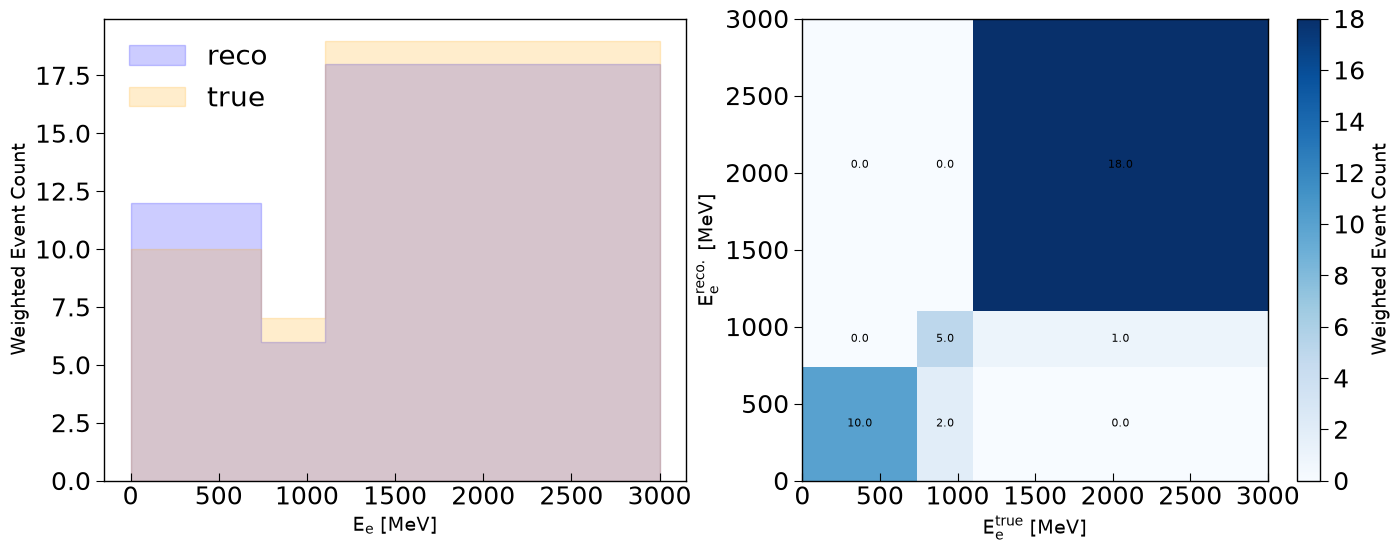

In [29]:
var_config = VariableConfig.electron_energy_default()
reco_col, truth_col = var_config.var_evt_reco_col, var_config.var_evt_truth_col
# reco_col  = ('rec', 'dlp', 'ele_energy_reco_GeV', '', '', '', '')
# truth_col = ('rec', 'dlp_true', 'ele_energy_true_GeV', '', '', '')

# evtdf = your fully reco-selected dataframe.
# Signal here is DLP truth-matched (true_signal1p | true_signalNp), not a single nuint_categ flag.
evtdf_signal = evtdf[SIGNAL_MASK_FN(evtdf)]

vmin, vmax = 0.0, 3000.0   # matches the analysis's existing electron-energy plot range
clip_range = np.array([vmin, vmax])
true_vals, _       = get_clipped_evts(evtdf_signal, truth_col, clip_range)
reco_vals, weights = get_clipped_evts(evtdf_signal, reco_col, clip_range)

result = determine_bins(
    true_vals.to_numpy(), reco_vals.to_numpy(),
    n_bins=6, population="reco", purity_threshold=0.6,
    vmin=vmin, vmax=vmax, weights=weights.to_numpy(),
)
result.print_table()
print(result.edges, "final n_bins:", result.n_bins_final, "merges:", result.merges_applied)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].hist(reco_vals, bins=result.edges, weights=weights, histtype='stepfilled', color='blue', label='reco', alpha=0.2, edgecolor='blue')
ax[0].hist(true_vals, bins=result.edges, weights=weights, histtype='stepfilled', color='orange', label='true', alpha=0.2, edgecolor='orange')
ax[0].legend()
ax[0].set_xlabel(var_config.var_labels[0])
ax[0].set_ylabel("Weighted Event Count")    

counts, xedges, yedges, _ = ax[1].hist2d(true_vals, reco_vals, bins=[result.edges, result.edges], weights=weights, cmap='Blues')
ax[1].set_xlabel(var_config.var_labels[2])
ax[1].set_ylabel(var_config.var_labels[1])
fig.colorbar(ax[1].collections[0], ax=ax[1], label="Weighted Event Count")

for i in range(len(xedges) - 1):
    for j in range(len(yedges) - 1):
        x_center = (xedges[i] + xedges[i + 1]) / 2
        y_center = (yedges[j] + yedges[j + 1]) / 2
        ax[1].text(x_center, y_center, f"{counts[i, j]:.1f}",
                   ha='center', va='center', fontsize=8, color='black')

[[10.  0.  0.]
 [ 2.  5.  0.]
 [ 0.  1. 18.]]


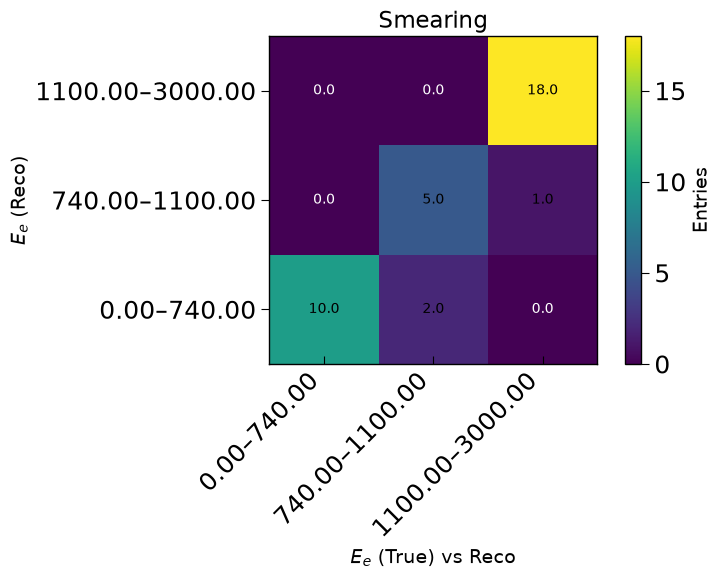

array([[10.,  0.,  0.],
       [ 2.,  5.,  0.],
       [ 0.,  1., 18.]])

In [32]:
# sanity-check plot: does the true-vs-reco histogram look diagonal on these edges?
get_smear_matrix(true_vals, reco_vals, bins_2d=[result.edges, result.edges],
                  weights=weights, var_labels=[r"$E_e$ (True)", r"$E_e$ (Reco)", r"$E_e$ (True) vs Reco"])
